In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import pandas as pd


In [2]:
import numpy as np

# =====================================================
# 5) INVERSE CDF LOOKUP (from experimental design) - basically entered values from the values used in the data for this mapping
# =====================================================
_manual_inv_cdf_vals = np.array([
    2.0,  2.5,  3.0,  4.0,  5.0,  7.5, 11.5, 16.0,
   18.5, 20.0, 21.0, 21.5, 22.0, 22.5, 23.0, 24.0,
   25.5, 28.0, 32.5, 36.5, 39.0, 40.0, 41.0, 41.5,
   42.0
])
# ======================================================
_manual_cdf_vals = np.array([2.0, 5.5, 8.0, 10.0, 11.0, 11.5,
    12.0, 12.5, 13.0, 14.0, 16.0, 18.5, 22.0, 25.5,
    28.0, 30.0, 31.0, 31.5, 32.0, 32.5, 33.0, 34.0, 36.0, 38.5, 42.0])
# ======================================================
_manual_linear_vals = np.array([2.0, 3.5, 5.5, 7.0, 8.5, 10.5, 12.0, 13.5,
    15.5, 17.0, 18.5, 20.5, 22.0, 23.5, 25.5, 27.0, 28.5, 30.5,
    32.0, 33.5, 35.5, 37.0, 38.5, 40.5, 42.0])

def value_function_ori(x, type):
    """
    Continuous value mapping on radians x ∈ [0, 2π].
    Types: 'scaled_cdf', 'scaled_inverse_cdf', 'linearIncrease'.
    Output range: [min_val, max_val] = [2, 42].
    """
    min_val, max_val = 2, 42
    x = np.asarray(x, dtype=float)

    if type == "scaled_cdf":
        grid = np.linspace(0, np.pi, _manual_cdf_vals.size)
        return np.interp(x, grid, _manual_cdf_vals)
    elif type == "scaled_inverse_cdf":
        grid = np.linspace(0, np.pi, _manual_inv_cdf_vals.size)
        return np.interp(x, grid, _manual_inv_cdf_vals)
    elif type == "linearIncrease":
        grid = np.linspace(0, np.pi, _manual_linear_vals.size)
        return np.interp(x, grid, _manual_linear_vals)
    else:
        raise ValueError(f"Unknown type '{type}'")


In [3]:
sns.set_context('talk')

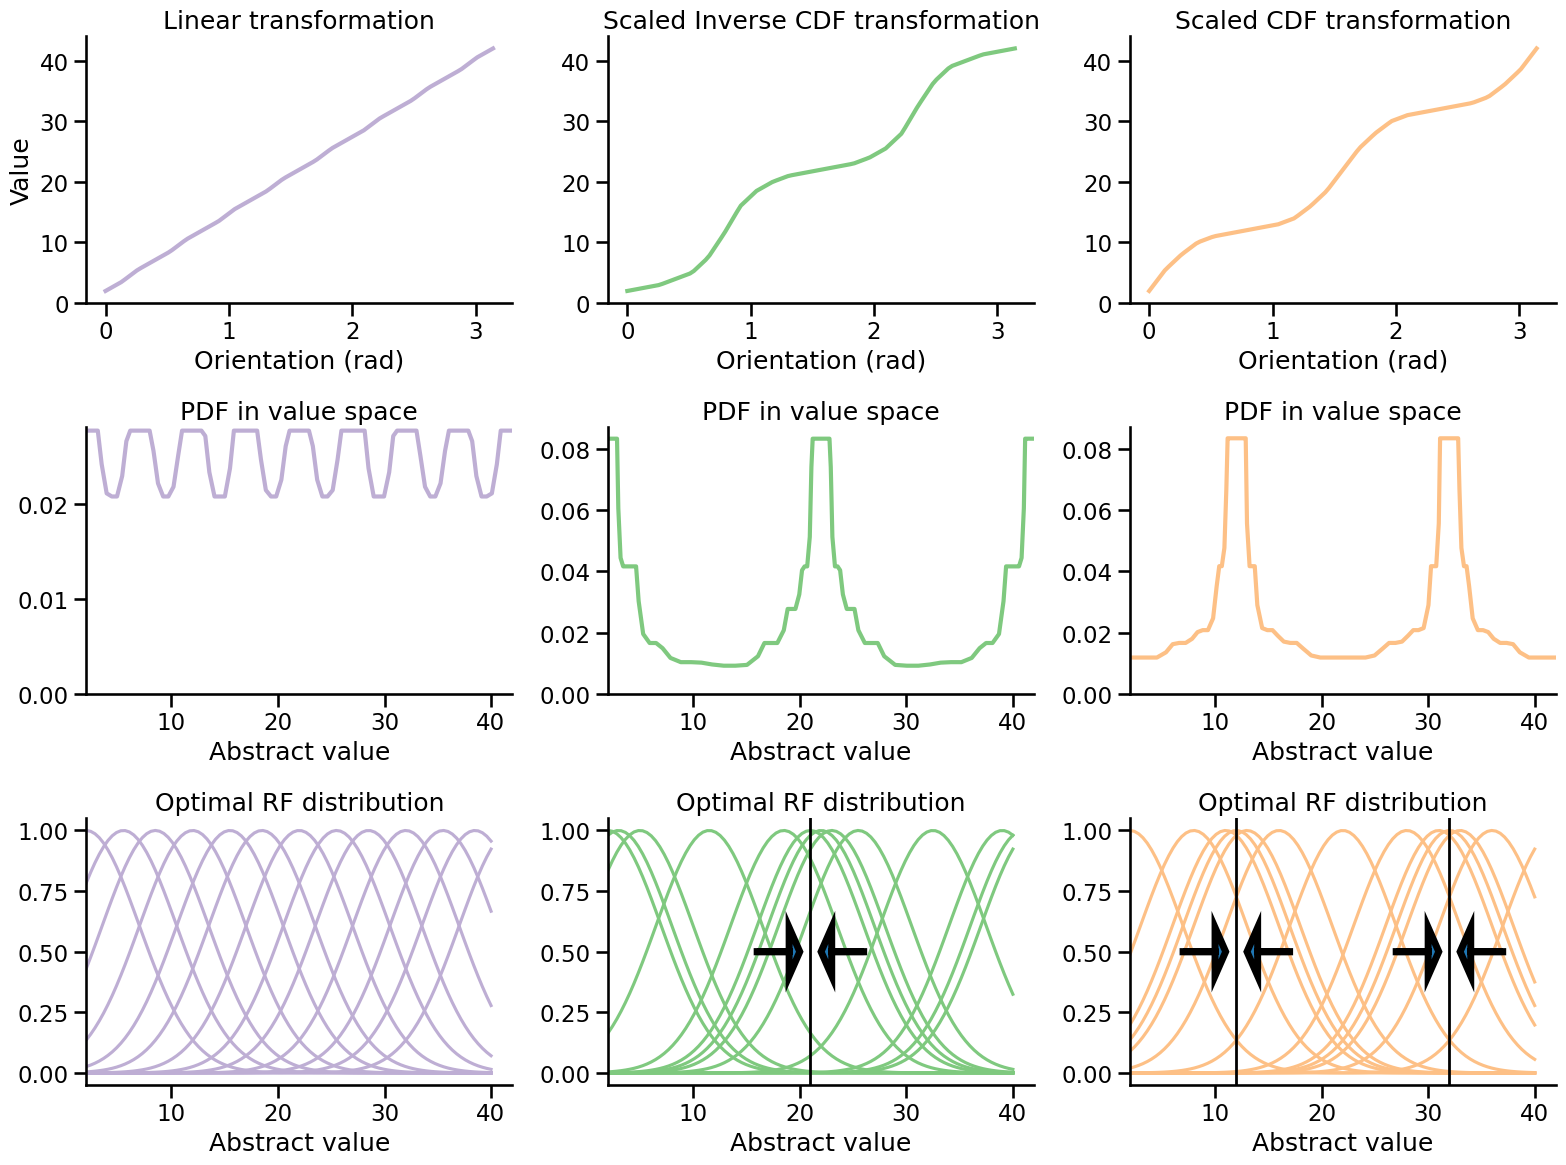

In [4]:
palette = ['k'] + sns.color_palette("tab10")

# Qualitative Accent
palette = np.array(sns.color_palette("Accent", n_colors=3))[[1,0,2]]


fig = plt.figure(figsize=(16, 12))

n_orientations = len(_manual_linear_vals)


for i, (p, type, label) in enumerate(zip(palette[0:3], 
                             ['linearIncrease', "scaled_inverse_cdf", "scaled_cdf"],
                             ["Linear", "Scaled Inverse CDF", "Scaled CDF"])):

    orientations = np.linspace(0, np.pi, 100)

    plt.subplot(3, 3, i+1)
    plt.title(f'{label} transformation')
    plt.plot(orientations, value_function_ori(orientations, type=type), color=p, label=label, lw=3)

    plt.xlabel('Orientation (rad)')
    if i == 0:
        plt.ylabel('Value')

    plt.subplot(3, 3, i+4)
    np.gradient(value_function_ori(orientations, type=type))

    plt.title('PDF in value space')

    values = value_function_ori(orientations, type=type)

    pdf_values = (1./np.pi)/ (np.gradient(values) / (orientations[1]-orientations[0]) )

    # plt.plot(value_function_ori(orientations, type=type), (1./2*np.pi)/ np.gradient(value_function_ori(orientations, type=type)), color=p)
    plt.plot(values, pdf_values, color=p, lw=3)
    plt.ylim(0, None)


    plt.xlim(2, 42)
    plt.xlabel('Abstract value')

    plt.subplot(3, 3, i+7)
    plt.title('Optimal RF distribution')

    orientations = np.linspace(0, np.pi, 13)

    for ori in value_function_ori(orientations, type=type):
        dist = ss.norm(loc=ori, scale=5)
        xs = np.linspace(0, 40, 100)
        max_y = dist.pdf(ori)
        ys = dist.pdf(xs) / max_y
        plt.plot(xs, ys, color=p)

    
    if label == 'Scaled Inverse CDF':
        plt.arrow(21+5, .5, -4, 0, head_width=.2, head_length=1, length_includes_head=True, lw=5, zorder=1000)
        plt.arrow(21-5, .5, 4, 0, head_width=.2, head_length=1, length_includes_head=True, lw=5, zorder=1000)

        plt.axvline(21, color='k', lw=2, zorder=1000)

    elif label == 'Scaled CDF':
        plt.arrow(32+5, .5, -4, 0, head_width=.2, head_length=1, length_includes_head=True, lw=5, zorder=1000)
        plt.arrow(32-5, .5, 4, 0, head_width=.2, head_length=1, length_includes_head=True, lw=5, zorder=1000)

        plt.arrow(12+5, .5, -4, 0, head_width=.2, head_length=1, length_includes_head=True, lw=5, zorder=1000)
        plt.arrow(12-5, .5, 4, 0, head_width=.2, head_length=1, length_includes_head=True, lw=5, zorder=1000)

        plt.axvline(12, color='k', lw=2, zorder=1000)
        plt.axvline(32, color='k', lw=2, zorder=1000)

    plt.xlim(2, 42)
    plt.xlabel('Abstract value')

    plt.tight_layout()



sns.despine()

Text(0, 0.5, 'Value (CHF)')

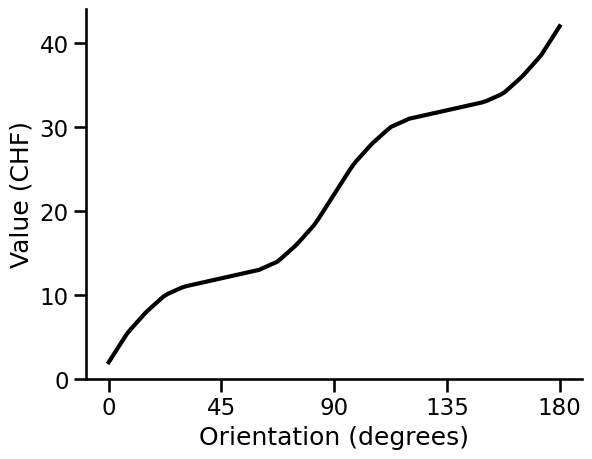

In [111]:
x = np.linspace(0, np.pi, 100)
plt.plot(np.rad2deg(x), value_function_ori(x, type='scaled_cdf'), color='k', lw=3)
sns.despine()

plt.xticks([0, 45, 90, 135, 180], [0, 45, 90, 135, 180])
plt.xlabel('Orientation (degrees)')
plt.ylabel('Value (CHF)')

Text(0, 0.5, 'Value (CHF)')

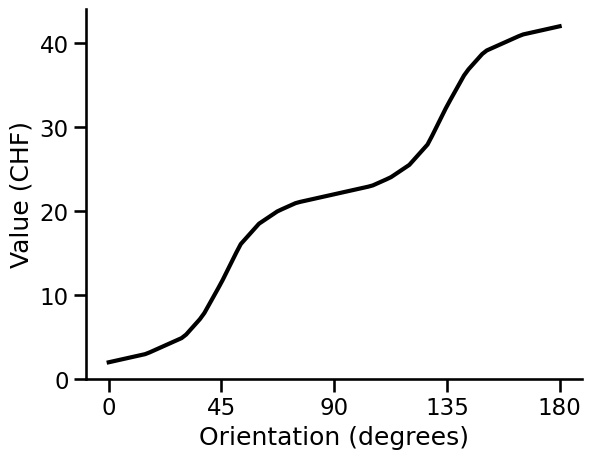

In [5]:
x = np.linspace(0, np.pi, 100)
plt.plot(np.rad2deg(x), value_function_ori(x, type='scaled_inverse_cdf'), color='k', lw=3)
sns.despine()

plt.xticks([0, 45, 90, 135, 180], [0, 45, 90, 135, 180])
plt.xlabel('Orientation (degrees)')
plt.ylabel('Value (CHF)')

In [6]:
# from braincoder.models import GaussianPRF
# import pandas as pd

NameError: name 'GaussianPRF' is not defined

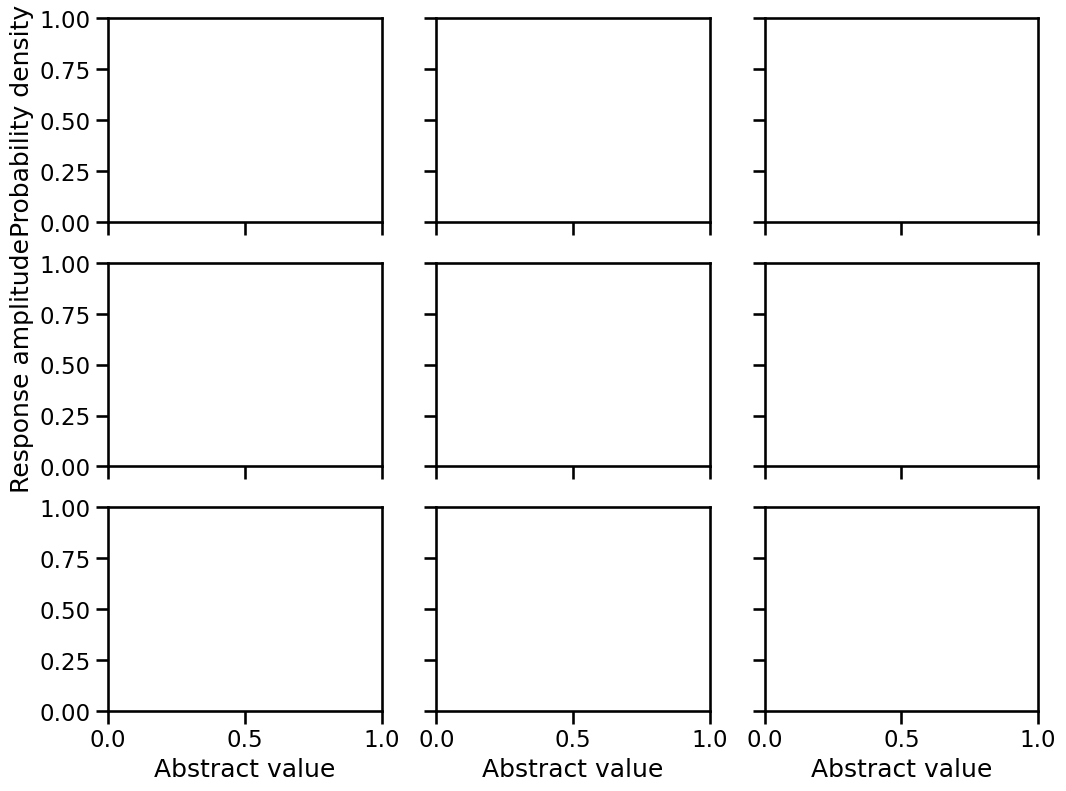

In [7]:
type = "scaled_cdf"

fig, axes = plt.subplots(3, 3, figsize=(12, 9))


# Top row should share y-axis, but all have y ticks of their own
for ax in axes[0, :]:
    ax.set_ylabel('Probability density')
    ax.label_outer()

for ax in axes[1, :]:
    ax.set_xlabel('Abstract value')
    ax.set_ylabel('Response amplitude')
    ax.label_outer()

for ax in axes[2, :]:
    ax.set_xlabel('Abstract value')
    ax.label_outer()


for i, (type, label) in enumerate(zip(['linearIncrease', "scaled_inverse_cdf", "scaled_cdf"],
                                ["Linear Increase", "Scaled Inverse CDF", "Scaled CDF"])):


    orientations = np.linspace(0, np.pi, 50)

    prf_centers = value_function_ori(orientations, type=type)

    parameters = pd.DataFrame({
        'mu': prf_centers,
        'sd': np.ones_like(prf_centers) * 1.,
        'amplitude': np.ones_like(prf_centers),
        'baseline': np.zeros_like(prf_centers)
    }).astype(np.float32)


    omega = np.identity(len(prf_centers), dtype=np.float32) * .5
    model = GaussianPRF(parameters=parameters, omega=omega)

    stimuli = np.linspace(2, 42, 100).astype(np.float32)

    ax = axes[0, i]
    values = value_function_ori(orientations, type=type)

    pdf_values = (1./np.pi)/ (np.gradient(values) / (orientations[1]-orientations[0]) )

    ax.plot(values, pdf_values, color=palette[i])
    ax.set_ylim(0, None)


    ax.set_xlim(2, 42)
    


    ax = axes[1, i]
    ax.set_ylabel("Amplitude response")
    ax.set_title("RFs for " + label)
    predictions = model.basis_predictions(stimuli).numpy()
    ax.plot(stimuli, predictions, color=palette[i], alpha=.25, lw=2)

    fi = model.get_fisher_information(stimuli, omega)

    ax = axes[2, i]
    ax.plot(stimuli, fi, c=palette[i])
    
    if i == 0:
        ax.set_ylabel('Fisher Information')

    ax.set_title('Fisher Information')


plt.tight_layout()
sns.despine()

<Axes: >

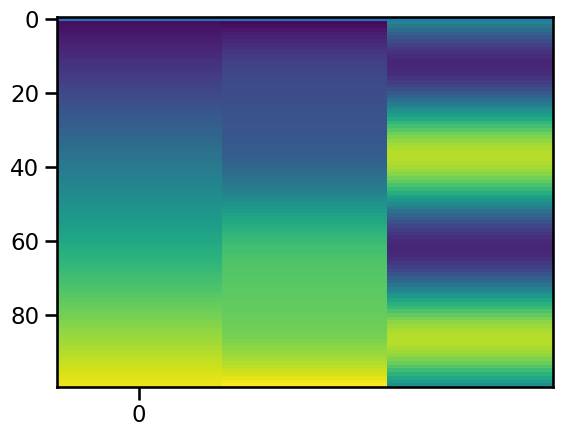

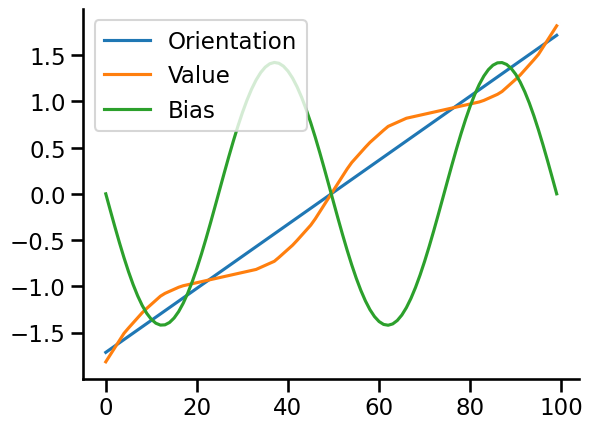

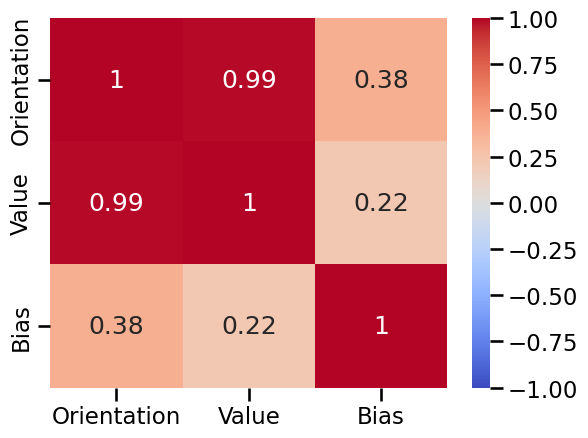

In [ ]:
type = 'scaled_cdf'

orientations = np.linspace(0, np.pi, 100)
values = value_function_ori(orientations, type=type)
bias = -np.sin(orientations*4)

plt.plot(np.rad2deg(orientations), -np.sin(orientations*4))

plt.xticks([0, 45, 90, 135, 180], [0, 45, 90, 135, 180])
plt.axhline(0.0)


# Put orientations, values and bias as columns in design matrix X
X = np.column_stack([orientations, values, bias])

# Zscore all columns
X = (X - X.mean(axis=0)) / X.std(axis=0)

X = pd.DataFrame(X, columns=['Orientation', 'Value', 'Bias'])

plt.imshow(X, aspect='auto', cmap='viridis')

plt.figure()
plt.plot(X)
plt.legend(X.columns)
sns.despine()

plt.figure()
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

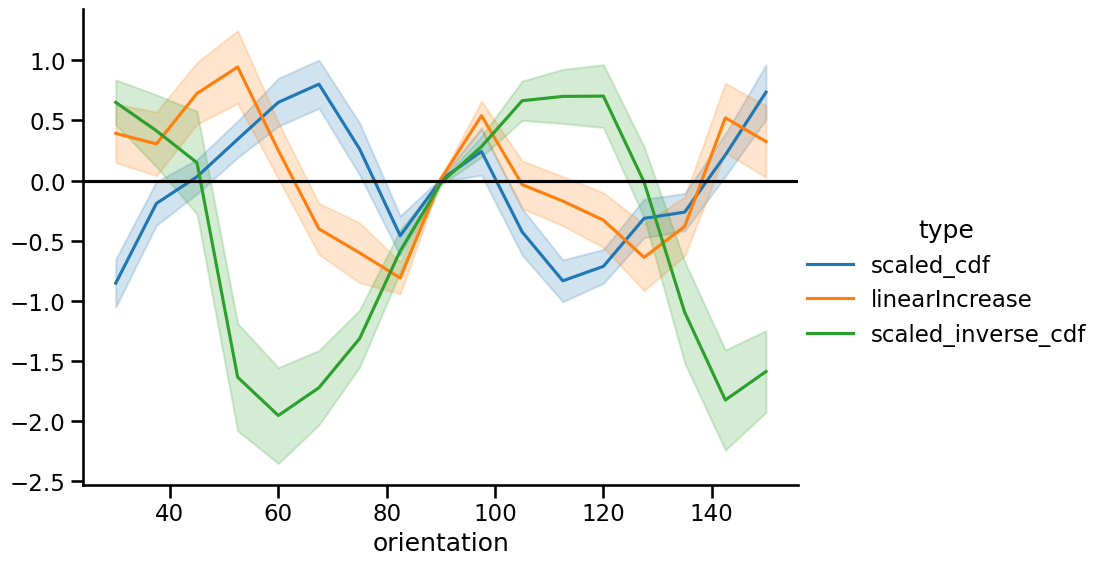

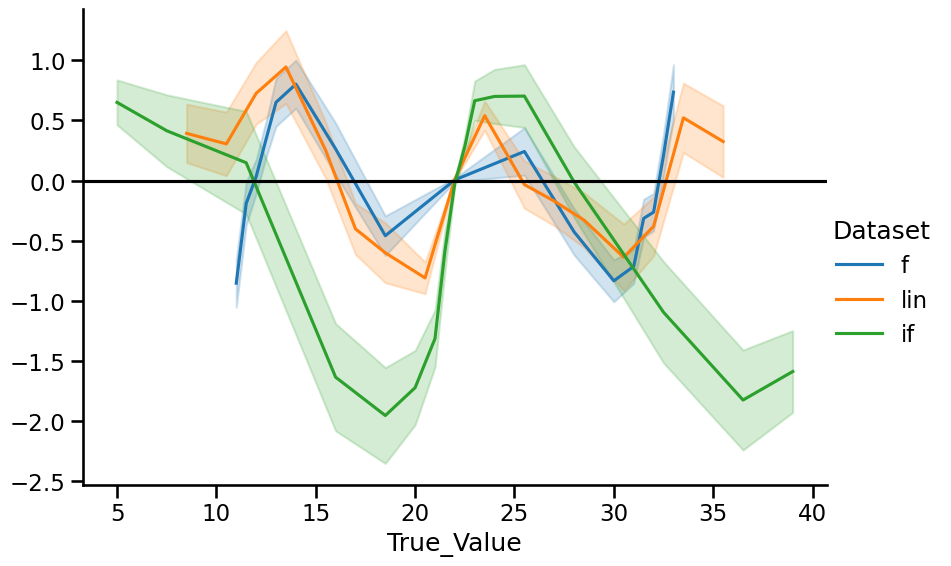

In [8]:
df = pd.read_csv('/Users/gdehol/Library/CloudStorage/ProtonDrive-gilles.de.hollander@proton.me-folder/Science/abstract_values/data/bedi2026.csv')

df['orientation'] = np.deg2rad(df['Gabor_Orientation'])

df['type'] = df['Dataset'].map({
    'lin': 'linearIncrease',
    'if': 'scaled_inverse_cdf',
    'f': 'scaled_cdf'
})

tmp = df.groupby(['pid', 'orientation', 'type'])['bias_test'].mean()

sns.relplot(x=np.rad2deg(tmp.index.get_level_values('orientation')),
            y=tmp.values,
            hue=tmp.index.get_level_values('type'),
            kind='line',
            errorbar='se',
            height=6,
            aspect=1.5)

plt.axhline(c='k')
tmp = df.groupby(['pid', 'True_Value', 'Dataset'])['bias_test'].mean()


# Smooth window of 3

sns.relplot(x=tmp.index.get_level_values('True_Value'),
            y=tmp.values,
            hue=tmp.index.get_level_values('Dataset'),
            kind='line',
            errorbar='se',
            height=6,
            aspect=1.5)

plt.axhline(0.0, c='k')

In [42]:
tmp = df.groupby(['pid', 'orientation', 'type'])['bias_test'].mean()
tmp = tmp.xs('scaled_cdf', level='type').unstack('orientation')

# Get rid of columns with nans
tmp = tmp.dropna(axis=1)

n_permutations = 1000
threshold = 2.0  # Use default threshold
tail = 0  # Two-tailed test

from scipy.stats import ttest_1samp
def stat_fun(x):
    t, _ = ttest_1samp(x, 0)
    return t

from mne.stats import permutation_cluster_test
T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    X=[np.asarray(tmp.astype(np.float32))],  # Your data (n_subjects x n_timepoints)
    n_permutations=n_permutations,
    threshold=threshold,
    stat_fun=stat_fun,
    # tail=tail,
    out_type='mask'  # Return boolean mask of significant clusters
)

# import matplotlib.pyplot as plt

# times = tmp.columns

# # Plot the average time series
# plt.plot(times, tmp.mean(axis=0), label='Average Time Series')

# # Identify significant clusters
# # Identify significant clusters (p < 0.05)
# significant_clusters = [(cluster, p_val) for cluster, p_val in zip(clusters, cluster_p_values) if p_val < 0.05]

# print(f"Significant clusters: {significant_clusters}")
# # Create a boolean mask of significant timepoints
# significant_mask = np.zeros_like(T_obs, dtype=bool)
# for cluster, _ in significant_clusters:
#     significant_mask[cluster] = True


# # Get the indices of significant timepoints
# significant_indices = np.where(significant_mask)[0]

# # Group contiguous timepoints into ranges
# from itertools import groupby
# from operator import itemgetter

# contiguous_ranges = []
# for k, g in groupby(enumerate(significant_indices), lambda x: x[0] - x[1]):
#     group = list(map(itemgetter(1), g))
#     contiguous_ranges.append((times[group[0]], times[group[-1]]))

# print(f"Contiguous significant time ranges: {contiguous_ranges}")


# import matplotlib.pyplot as plt

# # Plot the average time series
# plt.plot(times, tmp.mean(axis=0), label='Average Time Series')

# # Highlight significant ranges
# for start_time, end_time in contiguous_ranges:
#     plt.axvspan(start_time, end_time, color='red', alpha=0.3)

# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')

stat_fun(H1): min=-5.062261 max=4.004976
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

In [61]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from mne.stats import permutation_cluster_test
from itertools import groupby
from operator import itemgetter

def get_significant_orientations(group):
    """
    Identify significant orientations for a group of data using MNE's cluster-based permutation test.

    Args:
        group (pd.DataFrame or pd.Series): Data for a specific type, with orientations as columns.

    Returns:
        pd.DataFrame: DataFrame with columns ['start_orientation', 'end_orientation', 'p_value'].
    """
    def stat_fun(x):
        t, _ = ttest_1samp(x, 0)
        return t

    # Convert data to numpy array (orientations x measurements)
    X = np.asarray(group.astype(np.float32)).T  # Transpose to orientations x measurements

    # Run cluster test
    T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
        X=[X],
        n_permutations=1000,
        threshold=2.0,
        stat_fun=stat_fun,
        out_type='mask'
    )

    # Identify significant clusters
    significant_clusters = [(cluster, p_val) for cluster, p_val in zip(clusters, cluster_p_values) if p_val < 0.05]

    # Initialize a list to store results for this group
    results = []

    # Extract significant orientation ranges
    orientations = group.columns
    for cluster, p_val in significant_clusters:
        significant_mask = np.zeros_like(T_obs, dtype=bool)
        significant_mask[cluster] = True
        significant_indices = np.where(significant_mask)[0]

        # Group contiguous orientations into ranges
        for _, g in groupby(enumerate(significant_indices), lambda x: x[0] - x[1]):
            group_indices = list(map(itemgetter(1), g))
            start_orientation, end_orientation = orientations[group_indices[0]], orientations[group_indices[-1]]
            results.append({
                'start_orientation': start_orientation,
                'end_orientation': end_orientation,
                'p_value': p_val
            })

    # Convert results to a DataFrame
    return pd.DataFrame(results)


In [71]:
def get_significant_orientations(data, alpha=0.05, threshold=2.0, n_permutations=1000):
    """
    Identify significant orientations for each type in a pandas DataFrame/Series using MNE's cluster-based permutation test.

    Args:
        data (pd.DataFrame or pd.Series): Data with orientations as columns and types as rows or a MultiIndex.
        alpha (float): Significance level (default: 0.05).
        threshold (float): T-threshold for clustering (default: 2.0).
        n_permutations (int): Number of permutations (default: 1000).

    Returns:
        pd.DataFrame: DataFrame with columns ['type', 'start_orientation', 'end_orientation', 'p_value'].
    """
    def stat_fun(x):
        t, _ = ttest_1samp(x, 0)
        return t

    # Initialize a list to store results
    results = []


    X = data.unstack("orientation").dropna(axis=1)
    orientations = X.columns

    # Run cluster test
    T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
        X=[X],
        n_permutations=n_permutations,
        threshold=threshold,
        stat_fun=stat_fun,
        out_type='mask'
    )

    # return T_obs, clusters, cluster_p_values

    #     # Identify significant clusters
    significant_clusters = [(cluster, p_val) for cluster, p_val in zip(clusters, cluster_p_values) if p_val < alpha]

    results = pd.DataFrame(index=orientations)

    for cluster, p_val in significant_clusters:
        significant_mask = np.zeros_like(T_obs, dtype=bool)
        significant_mask[cluster] = True
        significant_indices = np.where(significant_mask)[0]
        results.loc[orientations[significant_indices], 'p_value'] = p_val
        results.loc[orientations[significant_indices], 'significant'] = True

    return results

    

In [102]:
significant_orientations = tmp.groupby('type').apply(get_significant_orientations, alpha=0.05, threshold=2.0, n_permutations=1000)

stat_fun(H1): min=-6.140319 max=4.455192
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.062261 max=4.004975
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.570159 max=4.063191
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

[0.13089969]
Type: linearIncrease, Significant range: 75.0° to 82.5°
[0.13089969 0.13089969 0.13089969 0.13089969 0.26179939 0.13089969
 0.13089969 0.13089969 0.26179939 0.13089969 0.13089969]
Type: scaled_inverse_cdf, Significant range: 52.5° to 82.5°
Type: scaled_inverse_cdf, Significant range: 97.5° to 120.0°
Type: scaled_inverse_cdf, Significant range: 135.0° to 150.0°
[0.13089969 0.13089969 0.65449847 0.13089969 0.13089969]
Type: scaled_cdf, Significant range: 52.5° to 67.5°
Type: scaled_cdf, Significant range: 105.0° to 120.0°


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1647737045.py:6: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g = sns.relplot(x='orientation',


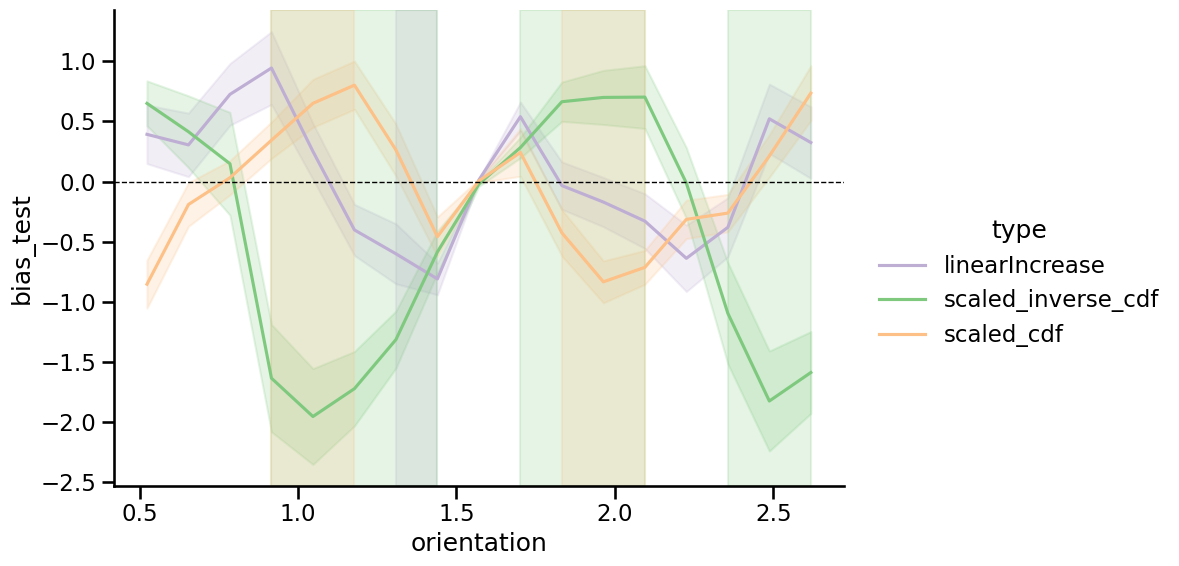

In [127]:
mean_biases = df.groupby(['pid', 'type', 'orientation'])['bias_test'].mean().to_frame()
mean_biases = mean_biases.join(significant_orientations, on=['type', 'orientation']).reset_index()

hue_order = ['linearIncrease', 'scaled_inverse_cdf', 'scaled_cdf']

g = sns.relplot(x='orientation',
                y='bias_test',
                hue='type',
                kind='line',
                data=mean_biases,
                errorbar='se',
                height=6,
                aspect=1.5,
                palette=palette,
                hue_order=hue_order)

g.map(plt.axhline, y=0.0, c='k', lw=1, ls='--')

axes = g.axes.flat
for ax in axes:
    for type_name in hue_order:
        type_data = mean_biases[mean_biases['type'] == type_name]
        significant_data = type_data[type_data['significant'] == True]

        if not significant_data.empty:
            # Get the significant orientations for this type
            orientations = significant_data['orientation'].unique()
            orientations = np.sort(orientations)

            if len(orientations) == 0:
                continue

            # Find contiguous ranges
            diffs = np.diff(orientations)
            print(diffs)
            breaks = np.where(diffs > (np.min(diffs) + 1e-6))[0]  # Adding a small epsilon to avoid floating-point precision issues
            start_indices = np.insert(breaks + 1, 0, 0)
            end_indices = np.append(breaks, len(orientations) - 1)

            for start_idx, end_idx in zip(start_indices, end_indices):
                start_orientation = orientations[start_idx]
                end_orientation = orientations[end_idx]
                ax.axvspan(start_orientation, end_orientation, alpha=0.2, color=palette[hue_order.index(type_name)])

                print(f"Type: {type_name}, Significant range: {np.rad2deg(start_orientation):.1f}° to {np.rad2deg(end_orientation):.1f}°")


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1073394886.py:6: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g = sns.relplot(


Type: linearIncrease, Significant range: 75.0° to 82.5° (p=0.031)
Type: scaled_inverse_cdf, Significant range: 52.5° to 82.5° (p=0.001)
Type: scaled_inverse_cdf, Significant range: 97.5° to 120.0° (p=0.001)
Type: scaled_inverse_cdf, Significant range: 135.0° to 150.0° (p=0.001)
Type: scaled_cdf, Significant range: 52.5° to 67.5° (p=0.032)
Type: scaled_cdf, Significant range: 105.0° to 120.0° (p=0.032)


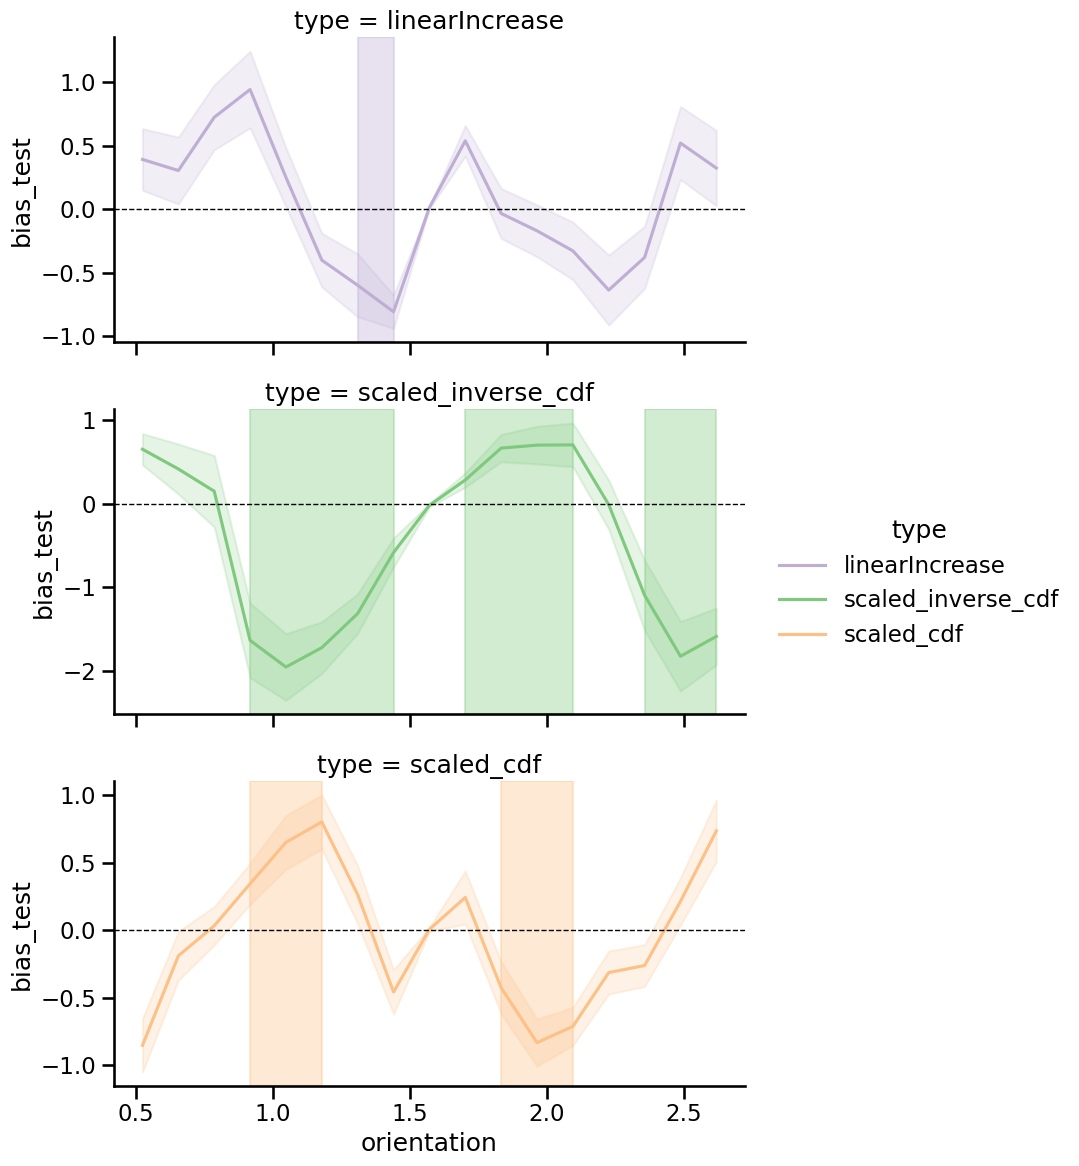

In [137]:
mean_biases = df.groupby(['pid', 'type', 'orientation'])['bias_test'].mean().to_frame()
mean_biases = mean_biases.join(significant_orientations, on=['type', 'orientation']).reset_index()

hue_order = ['linearIncrease', 'scaled_inverse_cdf', 'scaled_cdf']

g = sns.relplot(
    x='orientation',
    y='bias_test',
    row='type',
    kind='line',
    hue='type',
    row_order=hue_order,
    hue_order=hue_order,
    data=mean_biases,
    errorbar='se',
    height=4,
    aspect=2,
    palette=palette,
    facet_kws={'sharey': False, 'sharex': True}
)

g.map(plt.axhline, y=0.0, c='k', lw=1, ls='--')

# Iterate over each subplot axis and corresponding type
for ax, type_name in zip(g.axes.flat, hue_order):
    type_data = mean_biases[mean_biases['type'] == type_name]
    significant_data = type_data[type_data['significant'] == True]

    if not significant_data.empty:
        orientations = significant_data['orientation'].unique()
        orientations = np.sort(orientations)

        if len(orientations) == 0:
            continue

        diffs = np.diff(orientations)
        breaks = np.where(diffs > (np.min(diffs) + 1e-6))[0]
        start_indices = np.insert(breaks + 1, 0, 0)
        end_indices = np.append(breaks, len(orientations) - 1)

        for start_idx, end_idx in zip(start_indices, end_indices):
            start_orientation = orientations[start_idx]
            end_orientation = orientations[end_idx]
            ax.axvspan(start_orientation, end_orientation, alpha=0.35, color=palette[hue_order.index(type_name)])
            print(f"Type: {type_name}, Significant range: {np.rad2deg(start_orientation):.1f}° to {np.rad2deg(end_orientation):.1f}° (p={significant_data['p_value'].iloc[0]:.3f})")


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1290722137.py:11: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g = sns.relplot(


Type: linearIncrease, Significant range: 75.0° to 82.5°, (p=0.031)
Type: scaled_inverse_cdf, Significant range: 52.5° to 82.5°, (p=0.001)
Type: scaled_inverse_cdf, Significant range: 97.5° to 120.0°, (p=0.001)
Type: scaled_inverse_cdf, Significant range: 135.0° to 150.0°, (p=0.001)
Type: scaled_cdf, Significant range: 52.5° to 67.5°, (p=0.032)
Type: scaled_cdf, Significant range: 105.0° to 120.0°, (p=0.032)


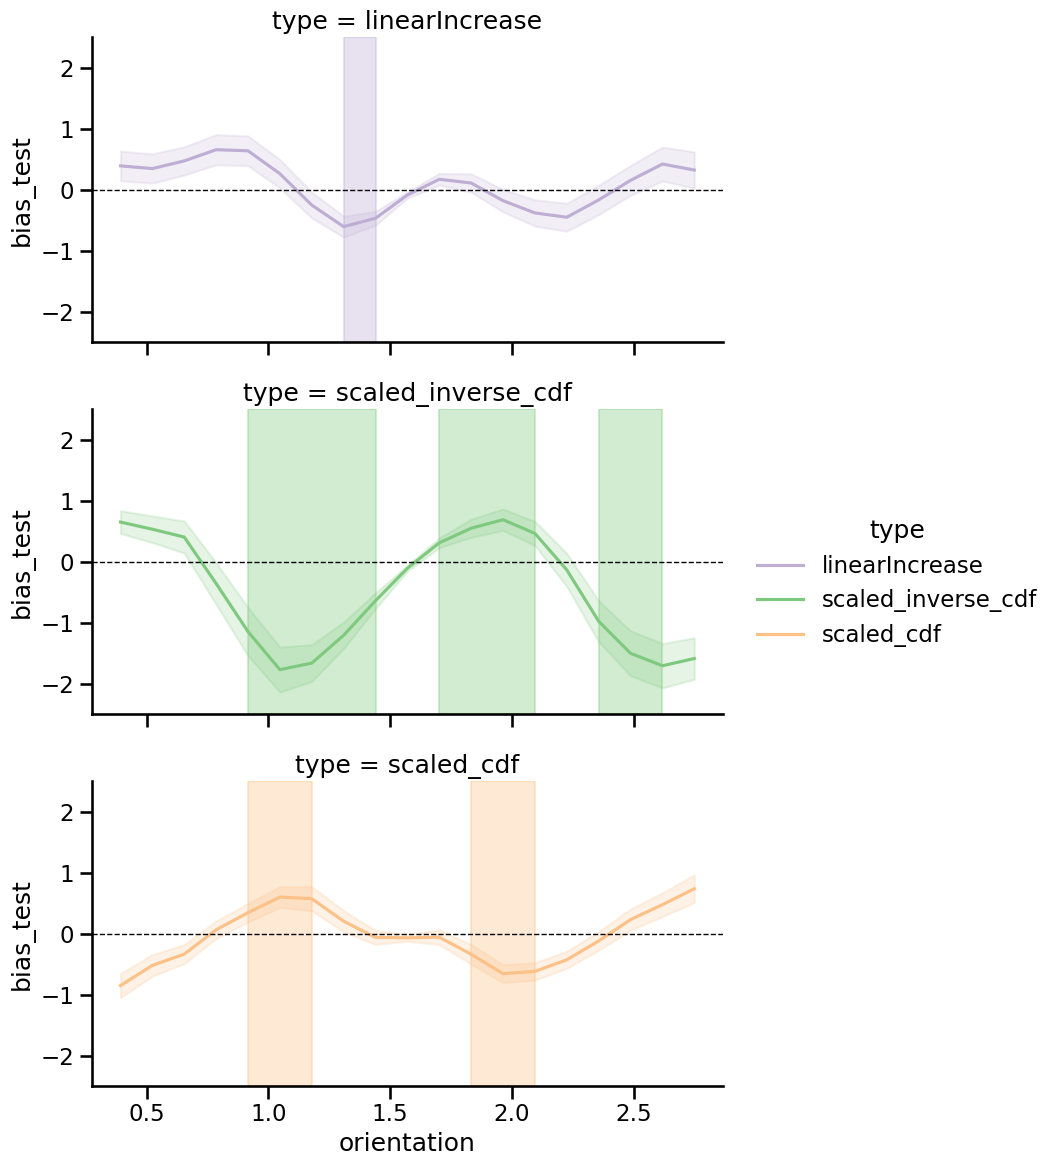

In [143]:
mean_biases = df.groupby(['pid', 'type', 'orientation'])['bias_test'].mean().to_frame()
mean_biases = mean_biases.join(significant_orientations, on=['type', 'orientation']).reset_index()


# Do a rolling mean with window size 3 per participant
mean_biases['bias_test'] = mean_biases.groupby(['pid', 'type'])['bias_test'].transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())


hue_order = ['linearIncrease', 'scaled_inverse_cdf', 'scaled_cdf']

g = sns.relplot(
    x='orientation',
    y='bias_test',
    row='type',
    kind='line',
    hue='type',
    row_order=hue_order,
    hue_order=hue_order,
    data=mean_biases,
    errorbar='se',
    height=4,
    aspect=2,
    palette=palette,
    facet_kws={'sharey': False, 'sharex': True}
)

g.map(plt.axhline, y=0.0, c='k', lw=1, ls='--')

# Iterate over each subplot axis and corresponding type
for ax, type_name in zip(g.axes.flat, hue_order):
    type_data = mean_biases[mean_biases['type'] == type_name]
    significant_data = type_data[type_data['significant'] == True]

    if not significant_data.empty:
        orientations = significant_data['orientation'].unique()
        orientations = np.sort(orientations)

        if len(orientations) == 0:
            continue

        diffs = np.diff(orientations)
        breaks = np.where(diffs > (np.min(diffs) + 1e-6))[0]
        start_indices = np.insert(breaks + 1, 0, 0)
        end_indices = np.append(breaks, len(orientations) - 1)

        for start_idx, end_idx in zip(start_indices, end_indices):
            start_orientation = orientations[start_idx]
            end_orientation = orientations[end_idx]
            ax.axvspan(start_orientation, end_orientation, alpha=0.35, color=palette[hue_order.index(type_name)])
            print(f"Type: {type_name}, Significant range: {np.rad2deg(start_orientation):.1f}° to {np.rad2deg(end_orientation):.1f}°, (p={significant_data['p_value'].iloc[0]:.3f})")

g.set(ylim=(-2.5, 2.5))

In [124]:
orientations

array([0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 0.91629786, 0.91629786, 0.91629786,
       0.91629786, 0.91629786, 1.04719755, 1.04719755, 1.04719755,
       1.04719755, 1.04719755, 1.04719755, 1.04719755, 1.04719755,
       1.04719755, 1.04719755, 1.04719755, 1.04719755, 1.04719755,
       1.04719755, 1.04719755, 1.04719755, 1.04719755, 1.04719755,
       1.04719755, 1.04719755, 1.04719755, 1.04719755, 1.04719755,
       1.04719755, 1.04719755, 1.04719755, 1.04719755, 1.04719755,
       1.04719755, 1.04719755, 1.04719755, 1.04719755, 1.04719

In [122]:
ax.axvspan(start_orientation, end_orientation, alpha=0.9, color=palette[hue_order.index(type_name)])

In [114]:
mean_biases.groupby(['orientation', 'type']).mean()

bias_test  p_value significant
orientation type                                              
0.130900    linearIncrease            NaN      NaN         NaN
            scaled_cdf                NaN      NaN         NaN
            scaled_inverse_cdf        NaN      NaN         NaN
0.261799    linearIncrease            NaN      NaN         NaN
            scaled_cdf                NaN      NaN         NaN
...                                   ...      ...         ...
2.879793    scaled_cdf                NaN      NaN         NaN
            scaled_inverse_cdf        NaN      NaN         NaN
3.010693    linearIncrease            NaN      NaN         NaN
            scaled_cdf                NaN      NaN         NaN
            scaled_inverse_cdf        NaN      NaN         NaN

[69 rows x 3 columns]

In [113]:
d

0     0.916298
1     1.047198
2     1.178097
3     1.308997
4     1.439897
5     1.701696
6     1.832596
7     1.963495
8     2.094395
9     2.356194
10    2.487094
11    2.617994
Name: orientation, dtype: float64

In [111]:
significant_data

bias_test  p_value significant
pid       type               orientation                                
01_143650 scaled_inverse_cdf 0.916298     -4.166667    0.001        True
                             1.047198     -2.045455    0.001        True
                             1.178097     -2.727273    0.001        True
                             1.308997     -2.300000    0.001        True
                             1.439897     -0.750000    0.001        True
...                                             ...      ...         ...
35_143652 scaled_inverse_cdf 1.963495     -0.500000    0.008        True
                             2.094395     -0.583333    0.008        True
                             2.356194      0.772727    0.015        True
                             2.487094      0.083333    0.015        True
                             2.617994     -1.500000    0.015        True

[444 rows x 3 columns]

In [106]:
type_name

'linearIncrease'

In [105]:
end_orientation

1.4398966328953218

In [104]:
start_orientation

1.3089969389957472

In [97]:
significant_data

bias_test  p_value significant
pid       type           orientation                                
00_114825 linearIncrease 1.308997     -0.166667    0.022        True
                         1.439897     -1.318182    0.022        True
01_114824 linearIncrease 1.308997     -1.833333    0.022        True
                         1.439897     -0.181818    0.022        True
02_114825 linearIncrease 1.308997      0.250000    0.022        True
...                                         ...      ...         ...
28_114826 linearIncrease 1.439897     -3.200000    0.022        True
29_114825 linearIncrease 1.308997     -0.681818    0.022        True
                         1.439897     -0.875000    0.022        True
30_114823 linearIncrease 1.308997     -2.000000    0.022        True
                         1.439897     -0.333333    0.022        True

[78 rows x 3 columns]

In [ ]:
mean_

In [93]:
mean_biases

bias_test  p_value significant
pid       type               orientation                                
00_093006 scaled_cdf         0.130900           NaN      NaN         NaN
                             0.261799           NaN      NaN         NaN
                             0.392699           NaN      NaN         NaN
                             0.523599     -0.041667      NaN         NaN
                             0.654498      0.583333      NaN         NaN
...                                             ...      ...         ...
35_143652 scaled_inverse_cdf 2.487094      0.083333    0.016        True
                             2.617994     -1.500000    0.016        True
                             2.748894           NaN      NaN         NaN
                             2.879793           NaN      NaN         NaN
                             3.010693           NaN      NaN         NaN

[2714 rows x 3 columns]

In [ ]:
significant_orientationsa

p_value significant
type               orientation                     
linearIncrease     0.523599         NaN         NaN
                   0.654498         NaN         NaN
                   0.785398         NaN         NaN
                   0.916298         NaN         NaN
                   1.047198         NaN         NaN
                   1.178097         NaN         NaN
                   1.308997       0.022        True
                   1.439897       0.022        True
                   1.570796         NaN         NaN
                   1.701696         NaN         NaN
                   1.832596         NaN         NaN
                   1.963495         NaN         NaN
                   2.094395         NaN         NaN
                   2.225295         NaN         NaN
                   2.356194         NaN         NaN
                   2.487094         NaN         NaN
                   2.617994         NaN         NaN
scaled_cdf         0.523599         NaN         NaN
                   0.654498         NaN         NaN
                   0.785398         NaN         NaN
                   0.916298       0.020        True
                   1.047198       0.020        True
                   1.178097       0.020        True
                   1.308997         NaN         NaN
                   1.439897         NaN         NaN
                   1.570796         NaN         NaN
                   1.701696         NaN         NaN
                   1.832596       0.010        True
                   1.963495       0.010        True
                   2.094395       0.010        True
                   2.225295         NaN         NaN
                   2.356194         NaN         NaN
                   2.487094         NaN         NaN
                   2.617994         NaN         NaN
scaled_inverse_cdf 0.523599         NaN         NaN
                   0.654498         NaN         NaN
                   0.785398         NaN         NaN
                   0.916298       0.001        True
                   1.047198       0.001        True
                   1.178097       0.001        True
                   1.308997       0.001        True
                   1.439897       0.001        True
                   1.570796         NaN         NaN
                   1.701696       0.010        True
                   1.832596       0.010        True
                   1.963495       0.010        True
                   2.094395       0.010        True
                   2.225295         NaN         NaN
                   2.356194       0.016        True
                   2.487094       0.016        True
                   2.617994       0.016        True

In [63]:
get_significant_time_ranges(tmp, tmp[~tmp.isnull()].index.unique('orientation'))

stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=0.221364 max=0.221364
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=1.131051 max=1.131051
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=1.778995 max=1.778995
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=-0.381200 max=-0.381200
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=-1.547819 max=-1.547819
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=-2.309036 max=-2.309036
Running initial clustering …
Found 1 cluster


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.528304 max=-3.528304
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

...

stat_fun(H1): min=-3.377976 max=-3.377976
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.652765 max=-1.652765
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=-0.681746 max=-0.681746
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_44162/1410046780.py:31: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, _ = permutation_cluster_test(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykerne

,orientation,start_time,end_time,p_value
0,1.178097,0.523599,0.523599,0.026
1,1.308997,0.523599,0.523599,0.002
2,1.439897,0.523599,0.523599,0.001
3,1.701696,0.523599,0.523599,0.001
4,2.225295,0.523599,0.523599,0.017
5,2.356194,0.523599,0.523599,0.001


In [52]:
tmp = df.groupby(['pid', 'orientation', 'type'])['bias_test'].mean()
get_significant_time_ranges(data=tmp.xs('scaled_cdf', level='type'))

UnboundLocalError: cannot access local variable 'clusters' where it is not associated with a value

In [45]:
cluster_p_values

array([0.018, 0.153, 0.138, 0.173, 0.004])

In [37]:
significant_clusters

[(slice(3, 6, None),), (slice(10, 13, None),)]

In [34]:
tmp

orientation,0.523599,0.654498,0.785398,0.916298,1.047198,1.178097,1.308997,1.439897,1.570796,1.701696,1.832596,1.963495,2.094395,2.225295,2.356194,2.487094,2.617994
pid,,,,,,,,,,,,,,,,,
00_093006,-0.041667,0.583333,0.375000,1.208333,1.000000,1.166667,1.750000,0.008333,0.000000,-0.166667,-0.291667,-1.636364,-0.541667,-0.083333,0.090909,0.458333,1.166667
01_093012,-1.636364,-0.136364,-0.300000,0.500000,0.250000,0.666667,0.083333,-0.800000,0.000000,0.750000,0.409091,-0.300000,-0.818182,-0.500000,-0.333333,1.333333,1.666667
01_124148,-1.208333,-1.333333,-0.666667,-1.125000,-0.400000,0.625000,0.454545,-0.136364,0.000000,0.500000,-1.772727,0.038462,0.818182,0.958333,0.208333,-0.333333,-0.250000
02_093011,0.545455,0.666667,1.916667,1.863636,1.666667,1.500000,1.166667,-1.000000,0.000000,-0.666667,-0.666667,-1.818182,-1.416667,-1.409091,-1.909091,-1.000000,-0.333333
02_124149,-1.318182,-1.125000,-0.700000,0.050000,0.900000,1.045455,0.500000,-0.045455,0.000000,0.416667,-0.750000,-1.458333,-0.954545,0.227273,0.045455,0.636364,0.458333
03_093011,0.090909,0.166667,0.916667,0.333333,0.230769,0.333333,-0.125000,-0.181818,-0.291667,0.045455,-0.272727,-0.090909,0.090909,0.166667,-0.083333,0.250000,0.833333
04_093011,-1.916667,-0.500000,-0.750000,1.227273,1.583333,0.916667,0.583333,-0.863636,0.000000,-0.916667,0.181818,-1.166667,-0.166667,-0.250000,-0.333333,1.000000,2.000000
04_124149,-0.100000,0.041667,0.038462,0.625000,1.772727,3.083333,1.750000,-0.272727,0.000000,1.166667,0.100000,-0.340000,-0.125000,0.500000,0.583333,0.909091,0.875000
05_093011,-1.363636,0.454545,-0.250000,0.583333,0.750000,0.541667,-0.208333,-0.291667,0.000000,-1.500000,-1.863636,-2.954545,-0.208333,-1.041667,-1.000000,0.666667,-0.125000


In [ ]:

# Define a simple t-test function for the permutation test


# Test the statistical function on your data
t_values = stat_fun(tmp)
print("T-values:", t_values)
print("Min T-value:", np.nanmin(t_values))
print("Max T-value:", np.nanmax(t_values))

T-values: [-4.27577306 -1.05018848  0.22733908  2.26816241  3.26089869  4.00497535
  1.21985699 -2.78586284  0.40620328  1.2271561  -2.21794418 -4.78465632
 -5.06226088 -1.96714559 -1.68574641  1.20527057  3.23181949]
Min T-value: -5.06226087771885
Max T-value: 4.004975346345028


In [26]:
tmp.dtypes

orientation
0.523599    float64
0.654498    float64
0.785398    float64
0.916298    float64
1.047198    float64
1.178097    float64
1.308997    float64
1.439897    float64
1.570796    float64
1.701696    float64
1.832596    float64
1.963495    float64
2.094395    float64
2.225295    float64
2.356194    float64
2.487094    float64
2.617994    float64
dtype: object

In [21]:
np.isnan(tmp).any()

orientation
0.523599    False
0.654498    False
0.785398    False
0.916298    False
1.047198    False
1.178097    False
1.308997    False
1.439897    False
1.570796    False
1.701696    False
1.832596    False
1.963495    False
2.094395    False
2.225295    False
2.356194    False
2.487094    False
2.617994    False
dtype: bool

In [16]:
tmp

orientation,0.523599,0.654498,0.785398,0.916298,1.047198,1.178097,1.308997,1.439897,1.570796,1.701696,1.832596,1.963495,2.094395,2.225295,2.356194,2.487094,2.617994
pid,,,,,,,,,,,,,,,,,
00_093006,-0.041667,0.583333,0.375000,1.208333,1.000000,1.166667,1.750000,0.008333,0.000000,-0.166667,-0.291667,-1.636364,-0.541667,-0.083333,0.090909,0.458333,1.166667
01_093012,-1.636364,-0.136364,-0.300000,0.500000,0.250000,0.666667,0.083333,-0.800000,0.000000,0.750000,0.409091,-0.300000,-0.818182,-0.500000,-0.333333,1.333333,1.666667
01_124148,-1.208333,-1.333333,-0.666667,-1.125000,-0.400000,0.625000,0.454545,-0.136364,0.000000,0.500000,-1.772727,0.038462,0.818182,0.958333,0.208333,-0.333333,-0.250000
02_093011,0.545455,0.666667,1.916667,1.863636,1.666667,1.500000,1.166667,-1.000000,0.000000,-0.666667,-0.666667,-1.818182,-1.416667,-1.409091,-1.909091,-1.000000,-0.333333
02_124149,-1.318182,-1.125000,-0.700000,0.050000,0.900000,1.045455,0.500000,-0.045455,0.000000,0.416667,-0.750000,-1.458333,-0.954545,0.227273,0.045455,0.636364,0.458333
03_093011,0.090909,0.166667,0.916667,0.333333,0.230769,0.333333,-0.125000,-0.181818,-0.291667,0.045455,-0.272727,-0.090909,0.090909,0.166667,-0.083333,0.250000,0.833333
04_093011,-1.916667,-0.500000,-0.750000,1.227273,1.583333,0.916667,0.583333,-0.863636,0.000000,-0.916667,0.181818,-1.166667,-0.166667,-0.250000,-0.333333,1.000000,2.000000
04_124149,-0.100000,0.041667,0.038462,0.625000,1.772727,3.083333,1.750000,-0.272727,0.000000,1.166667,0.100000,-0.340000,-0.125000,0.500000,0.583333,0.909091,0.875000
05_093011,-1.363636,0.454545,-0.250000,0.583333,0.750000,0.541667,-0.208333,-0.291667,0.000000,-1.500000,-1.863636,-2.954545,-0.208333,-1.041667,-1.000000,0.666667,-0.125000


In [ ]:
mean_bias = df.groupby(['type', 'orientation'])['bias_test'].mean()
mean_bias = mean_bias.dropna().to_frame('empirical_bias').sort_index()

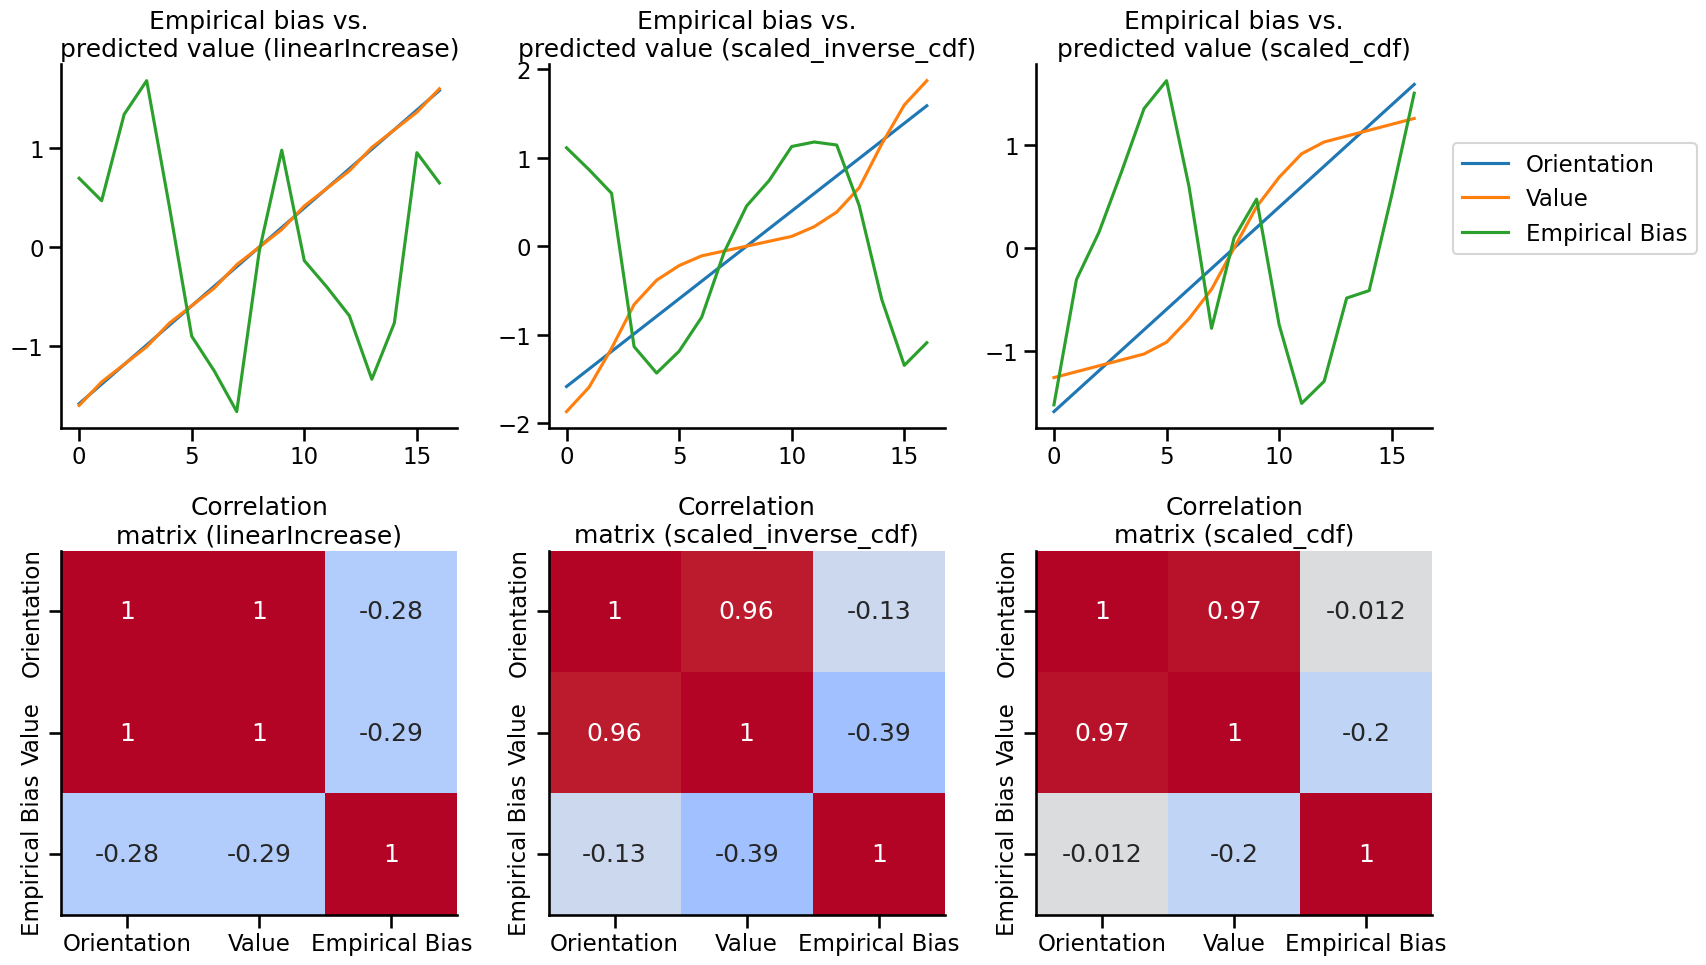

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming mean_bias and value_function_ori are defined elsewhere
types = ['linearIncrease', "scaled_inverse_cdf", "scaled_cdf"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, type in enumerate(types):
    # Plot empirical bias vs. predicted value
    orientations = mean_bias.index.unique(level='orientation')
    values = value_function_ori(orientations, type=type)

    X = pd.DataFrame(
        np.column_stack([orientations, values, mean_bias.loc[type]['empirical_bias']]),
        columns=['Orientation', 'Value', 'Empirical Bias']
    )
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    # Line plot (top row)
    ax1 = axes[0, i]
    X.plot(ax=ax1)
    ax1.set_title(f'Empirical bias vs.\npredicted value ({type})')
    ax1.legend().set_visible(False)  # Hide individual legends

    # Correlation matrix (bottom row)
    ax2 = axes[1, i]
    sns.heatmap(X.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax2, cbar=False)
    ax2.set_title(f'Correlation\nmatrix ({type})')

# Single legend for all line plots (top-right outside the subplots)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.15, 0.85))

plt.tight_layout()
sns.despine()
plt.show()


In [ ]:
df.columns

Index(['Gabor_Orientation', 'Value', 'Trial_Number', 'Try_Number',
       'True_Value', 'Submitted_Value', 'Submitted_Bid', 'Random_Price',
       'Outcome', 'Angle_Value', 'Numeric_Value', 'Choice', 'Start_Time',
       'End_Time', 'Choice_Time', 'Payout', 'Value_Function', 'Contrast',
       'Dual_True_Value', 'Dual_Input', 'Dual_Start_Time', 'Dual_Submit_Time',
       'Participant', 'Duration', 'Decision_Time', 'Trial_Block', 'error',
       'abs_error', 'is_outlier', 'folder', 'pid', 'Seat', 'StartTime',
       'Folder', 'Dataset', 'bias_train', 'bias_test', 'orientation', 'type'],
      dtype='object')

In [ ]:
df

,Gabor_Orientation,Value,Trial_Number,Try_Number,True_Value,Submitted_Value,Submitted_Bid,Random_Price,Outcome,Angle_Value,...,folder,pid,Seat,StartTime,Folder,Dataset,bias_train,bias_test,orientation,type
0,45.0,NaN,0.0,NaN,12.0,NaN,NaN,NaN,NaN,NaN,...,sess1_raw,18_124821,18,124821,sess1_raw,lin,NaN,NaN,0.785398,linearIncrease
1,37.5,NaN,2.0,NaN,10.5,7.0,NaN,NaN,NaN,NaN,...,sess1_raw,18_124821,18,124821,sess1_raw,lin,-3.5,NaN,0.654498,linearIncrease
2,172.5,NaN,3.0,NaN,40.5,40.5,NaN,NaN,NaN,NaN,...,sess1_raw,18_124821,18,124821,sess1_raw,lin,0.0,NaN,3.010693,linearIncrease
3,60.0,NaN,4.0,NaN,15.5,17.0,NaN,NaN,NaN,NaN,...,sess1_raw,18_124821,18,124821,sess1_raw,lin,1.5,NaN,1.047198,linearIncrease
4,37.5,NaN,5.0,NaN,10.5,13.5,NaN,NaN,NaN,NaN,...,sess1_raw,18_124821,18,124821,sess1_raw,lin,3.0,NaN,0.654498,linearIncrease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50644,150.0,NaN,199.0,NaN,39.0,NaN,32.5,11.0,Win,NaN,...,sess4_raw,29_143650,29,143650,sess4_raw,if,NaN,-6.5,2.617994,scaled_inverse_cdf
50645,97.5,NaN,200.0,NaN,22.5,NaN,22.0,30.0,Lose,NaN,...,sess4_raw,29_143650,29,143650,sess4_raw,if,NaN,-0.5,1.701696,scaled_inverse_cdf
50646,105.0,NaN,201.0,NaN,23.0,NaN,23.0,42.0,Lose,NaN,...,sess4_raw,29_143650,29,143650,sess4_raw,if,NaN,0.0,1.832596,scaled_inverse_cdf
50647,135.0,NaN,202.0,NaN,32.5,NaN,32.5,39.5,Lose,NaN,...,sess4_raw,29_143650,29,143650,sess4_raw,if,NaN,0.0,2.356194,scaled_inverse_cdf


17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17


Text(0.5, 1.05, 'Correlations between VALUE and BIAS (per subject)')

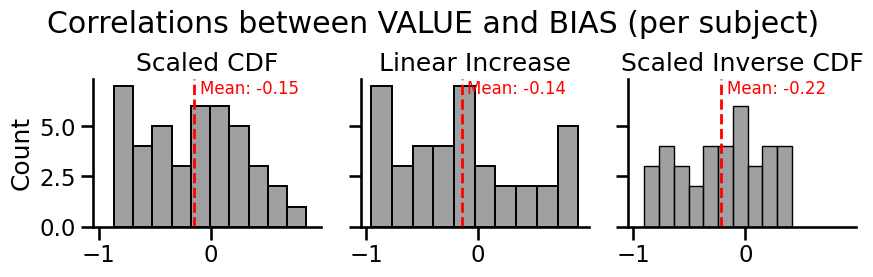

In [ ]:
import pingouin as pg

subwise_biases = df.groupby(['Participant', 'type', 'orientation'])['bias_test'].mean()

r = []

for (sub, type), d in subwise_biases.groupby(level=['Participant', 'type']):
    # plt.plot(np.rad2deg(d.index.get_level_values('orientation')), d.values, alpha=0.3)
    # plt.title(f'Subject {sub} - {type}')
    # plt.xlabel('Orientation (deg)')
    # plt.ylabel('Bias')
    # plt.axhline(0.0, color='k', lw=2)

    X = pd.DataFrame(
        np.column_stack([
            d.index.get_level_values('orientation'),
            value_function_ori(d.index.get_level_values('orientation'), type=type),
            d.values
        ]),
        columns=['Orientation', 'Value', 'Bias']
    )
    # X = (X - X.mean(axis=0)) / X.std(axis=0)

    # r.append(((sub, type), X.corr().loc['Value', 'Bias']))
    r.append({'subject': sub, 'type': type, 'corr_value_bias': pg.corr(X['Value'], X['Bias'])['r'].values[0]})
    print((~X['Bias'].isnull()).sum())



r = pd.DataFrame(r)
r['type'] = r['type'].map({
    'linearIncrease': 'Linear Increase',
    'scaled_inverse_cdf': 'Scaled Inverse CDF',
    'scaled_cdf': 'Scaled CDF'
})

g= sns.FacetGrid(r, col='type')
g.map(sns.histplot, 'corr_value_bias', bins=10, kde=False, color='gray')

g.set(xlabel=None)
g.set_titles(col_template='{col_name}')

# Add the mean line
for ax, (type, d) in zip(g.axes.flat, r.groupby('type')):
    mean_corr = d['corr_value_bias'].mean()
    ax.axvline(mean_corr, color='red', linestyle='--', lw=2)
    ax.text(mean_corr + 0.05, ax.get_ylim()[1]*0.9, f'Mean: {mean_corr:.2f}', color='red', fontsize=12)

g.fig.suptitle('Correlations between VALUE and BIAS (per subject)', y=1.05)

So as a subject we have knowledge about the value of a stimulus. It's true value is $V$. We will give our willigness to pay for it $v$.
 e can now join an auction, where a random number $b$ is drawn between the minimum possible value 2 and the maximum possible value 42:
$ b ~ U(2, 42) $
The probability of winning the bid is 
$\integral $

In [33]:
import numpy as np
import matplotlib.pyplot as plt


true_value = 40
range_ = (2, 42)
n_bids = 10000
possible_values = np.arange(range_[0], range_[1]+.5, 0.5)
# possible_bids = np.arange(range_[0], range_[1]+.5, 0.5)

# n_samples x actual bids x actual value
samples = np.random.uniform(low=range_[0], high=range_[1], size=(n_bids, len(possible_values), len(possible_values)))

true_values = possible_values[np.newaxis, np.newaxis, :]
possible_bids = possible_values[np.newaxis, :, np.newaxis]
error = possible_bids - true_values

# Round to nearest 0.5
samples = np.round(samples * 2) / 2
result = true_values - possible_bids
accepted = possible_bids >= samples
payment = accepted * samples

profit = (true_values - payment) * accepted


expected_profit = np.mean(profit, axis=0)


expected_profit

array([[ 0.000000e+00,  3.500000e-03,  7.000000e-03, ...,  2.691000e-01,
         2.133000e-01,  2.280000e-01],
       [-5.600000e-03,  3.050000e-03,  1.120000e-02, ...,  6.765500e-01,
         7.440500e-01,  7.338500e-01],
       [-1.850000e-02, -2.650000e-03,  1.235000e-02, ...,  1.321100e+00,
         1.275350e+00,  1.181850e+00],
       ...,
       [-1.907345e+01, -1.871510e+01, -1.821190e+01, ...,  1.899540e+01,
         1.965870e+01,  2.009335e+01],
       [-1.973005e+01, -1.919195e+01, -1.877475e+01, ...,  1.913535e+01,
         1.958825e+01,  2.004670e+01],
       [-1.989720e+01, -1.960455e+01, -1.894475e+01, ...,  1.905740e+01,
         1.949660e+01,  1.996505e+01]])

In [43]:
import pandas as pd
import seaborn as sns

err = pd.DataFrame(error.squeeze(), index=pd.Index(possible_bids.squeeze(), name='bid'), columns=pd.Index(possible_values, name='true_value'))

ep = pd.DataFrame(expected_profit.squeeze(), index=pd.Index(possible_bids.squeeze(), name='bid'), columns=pd.Index(possible_values, name='true_value'))


df = err.stack().to_frame('error').join(ep.stack().to_frame('expected_profit')).reset_index()

<Axes: xlabel='abs(error)', ylabel='true_value'>

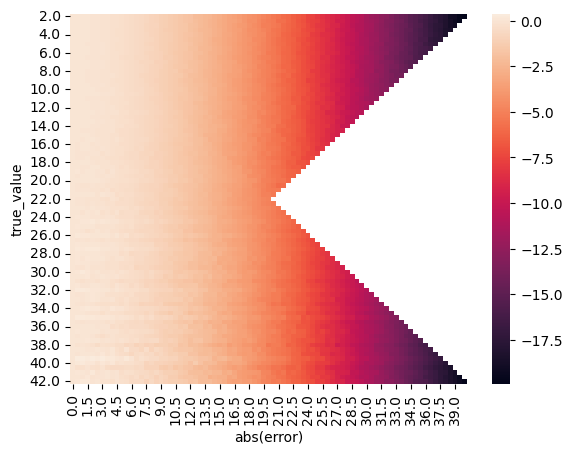

In [53]:
df['abs(error)'] = np.abs(df['error'])

cost = df.pivot_table(index='true_value', columns='abs(error)', values='expected_profit')
cost = cost - cost[0.0].values[:, np.newaxis]

sns.heatmap(cost)

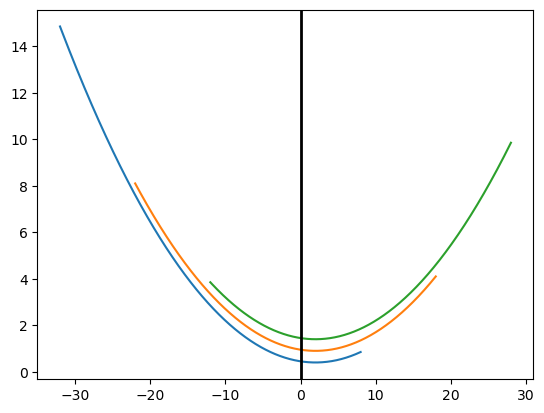

In [65]:
V = 20

x = np.linspace(2, 42, 1000)

for V in [10, 20, 30]:
    plt.plot(V - x, ((V-x)**2 + 4*x - 4)/80, label=f'V={V}')

plt.axvline(0.0, color='k', lw=2)

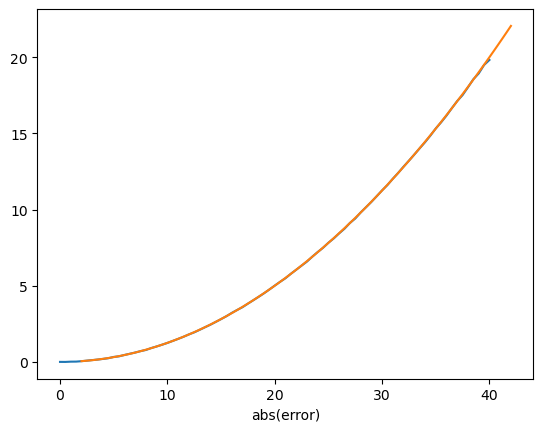

In [69]:
(-cost).mean(0).plot()

x = np.linspace(2, 42, 100)
plt.plot(x, x**2/80)

In [52]:
df

,bid,true_value,error,expected_profit,abs(error)
0,2.0,2.0,0.0,0.00000,0.0
1,2.0,2.5,-0.5,0.00350,0.5
2,2.0,3.0,-1.0,0.00700,1.0
3,2.0,3.5,-1.5,0.00900,1.5
4,2.0,4.0,-2.0,0.01200,2.0
...,...,...,...,...,...
6556,42.0,40.0,2.0,18.08650,2.0
6557,42.0,40.5,1.5,18.57345,1.5
6558,42.0,41.0,1.0,19.05740,1.0
6559,42.0,41.5,0.5,19.49660,0.5


In [32]:
error.shape

(10000, 81, 81)

In [ ]:

# Make a dataframe that I can use to plot the cost of one unit of error for different true values

true_values = np.arange(range_[0], range_[1]+.5, 0.5)
costs = []  

(10000, 81, 81)

Unimodal posterior.


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_2715/2225525427.py:16: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return np.exp(-f_s) * (f_s ** r) / np.math.factorial(int(r))


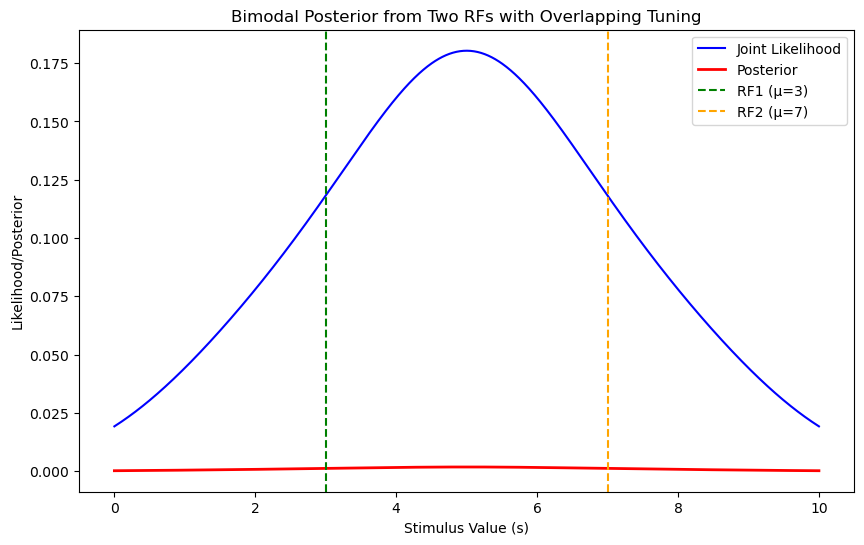

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# Define Gaussian tuning curves for two RFs
def gaussian_tuning(s, mu, sigma, A=1.0):
    return A * np.exp(-0.5 * ((s - mu) / sigma) ** 2)

# Define h-kernels for Poisson noise (log of tuning curve)
def h_kernel_poisson(s, mu, sigma, A=1.0):
    return np.log(gaussian_tuning(s, mu, sigma, A) + 1e-10)  # Avoid log(0)

# Define likelihood for a single RF (Poisson)
def likelihood_poisson(s, r, mu, sigma, A=1.0):
    f_s = gaussian_tuning(s, mu, sigma, A)
    return np.exp(-f_s) * (f_s ** r) / np.math.factorial(int(r))

# Define joint likelihood for two RFs
def joint_likelihood(s_range, r1, r2, mu1, sigma1, mu2, sigma2, A1=1.0, A2=1.0):
    lik1 = likelihood_poisson(s_range, r1, mu1, sigma1, A1)
    lik2 = likelihood_poisson(s_range, r2, mu2, sigma2, A2)
    return lik1 * lik2

# Define posterior (assuming flat prior)
def posterior(s_range, joint_likelihood):
    return joint_likelihood / np.sum(joint_likelihood)  # Normalize

# Parameters for two RFs
mu1, sigma1 = 3, 2
mu2, sigma2 = 7, 2
r1, r2 = 0.5, 0.5  # Observed activities

# Stimulus range
s_range = np.linspace(0, 10, 1000)

# Compute joint likelihood and posterior
joint_lik = joint_likelihood(s_range, r1, r2, mu1, sigma1, mu2, sigma2)
post = posterior(s_range, joint_lik)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(s_range, joint_lik, label="Joint Likelihood", color="blue")
plt.plot(s_range, post, label="Posterior", color="red", linewidth=2)
plt.axvline(x=mu1, color="green", linestyle="--", label=f"RF1 (μ={mu1})")
plt.axvline(x=mu2, color="orange", linestyle="--", label=f"RF2 (μ={mu2})")
plt.xlabel("Stimulus Value (s)")
plt.ylabel("Likelihood/Posterior")
plt.title("Bimodal Posterior from Two RFs with Overlapping Tuning")
plt.legend()

# Detect bimodality
peaks = argrelextrema(post, np.greater)[0]
if len(peaks) > 1:
    print(f"Bimodal posterior with peaks at s = {s_range[peaks]}")
else:
    print("Unimodal posterior.")

plt.show()


Bimodal posterior with peaks at s = [0.97097097 5.03503504]


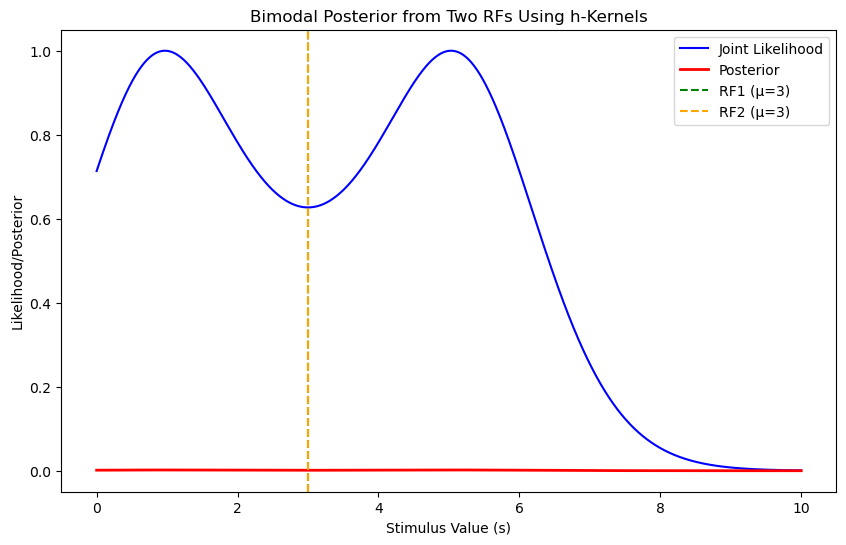

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# Define Gaussian tuning curves for two RFs
def gaussian_tuning(s, mu, sigma, A=1.0):
    return A * np.exp(-0.5 * ((s - mu) / sigma) ** 2)

# Define h-kernels for Poisson noise (log of tuning curve)
def h_kernel_poisson(s, mu, sigma, A=1.0):
    return np.log(gaussian_tuning(s, mu, sigma, A) + 1e-10)  # Avoid log(0)

# Define log-likelihood for a single RF using h-kernels
def log_likelihood_poisson(s, r, mu, sigma, A=1.0):
    h_s = h_kernel_poisson(s, mu, sigma, A)
    f_s = gaussian_tuning(s, mu, sigma, A)
    return np.dot(h_s, r) - f_s  # log p(r|s) = h(s)^T r - f(s) + const.

# Define joint log-likelihood for two RFs using h-kernels
def joint_log_likelihood(s_range, r1, r2, mu1, sigma1, mu2, sigma2, A1=1.0, A2=1.0):
    log_lik1 = log_likelihood_poisson(s_range, r1, mu1, sigma1, A1)
    log_lik2 = log_likelihood_poisson(s_range, r2, mu2, sigma2, A2)
    return log_lik1 + log_lik2

# Define posterior (assuming flat prior)
def posterior(s_range, log_joint_likelihood):
    joint_likelihood = np.exp(log_joint_likelihood - np.max(log_joint_likelihood))  # Avoid numerical underflow
    return joint_likelihood / np.sum(joint_likelihood)  # Normalize

# Parameters for two RFs with closer centers and higher observed activities
mu1, sigma1 = 3, 1.5
mu2, sigma2 = 3, 1.5
r1, r2 = 0.4, 0.4  # Higher observed activities to create ambiguity

# Stimulus range
s_range = np.linspace(0, 10, 1000)

# Compute joint log-likelihood and posterior using h-kernels
log_joint_lik = joint_log_likelihood(s_range, r1, r2, mu1, sigma1, mu2, sigma2)
post = posterior(s_range, log_joint_lik)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(s_range, np.exp(log_joint_lik - np.max(log_joint_lik)), label="Joint Likelihood", color="blue")
plt.plot(s_range, post, label="Posterior", color="red", linewidth=2)
plt.axvline(x=mu1, color="green", linestyle="--", label=f"RF1 (μ={mu1})")
plt.axvline(x=mu2, color="orange", linestyle="--", label=f"RF2 (μ={mu2})")
plt.xlabel("Stimulus Value (s)")
plt.ylabel("Likelihood/Posterior")
plt.title("Bimodal Posterior from Two RFs Using h-Kernels")
plt.legend()

# Detect bimodality
peaks = argrelextrema(post, np.greater)[0]
if len(peaks) > 1:
    print(f"Bimodal posterior with peaks at s = {s_range[peaks]}")
else:
    print("Unimodal posterior.")

plt.show()


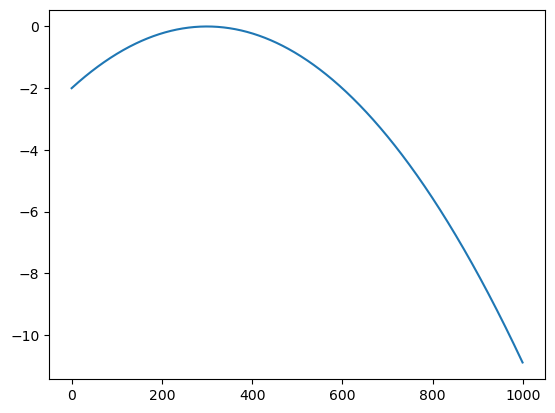

In [95]:
plt.plot(h_kernel_poisson(s_range, mu2, sigma1))


In [80]:
1

1

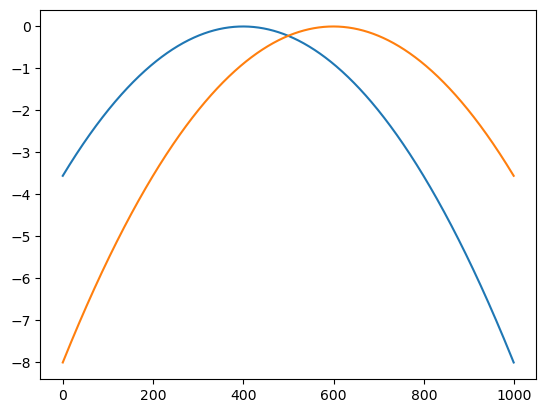

In [79]:
plt.plot(h_kernel_poisson(s_range, mu1, sigma1))
plt.plot(h_kernel_poisson(s_range, mu2, sigma1))